# <b>QC and Clean Data</b>
The raw matrix is subjected to Quality Control (QC) and cleaning to retain healthy, informative cells and well-expressed genes.

---

## 1. Setup Environment

### 1.1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scanpy as sc
import scrublet as scr

print("All libraries imported successfully.")

All libraries imported successfully.


### 1.2. Define File Paths/Directories

In [2]:
import config

# Raw AnnData file
RAW_ANNDATA_FILE = config.RAW_ANNDATA_FILE
print("Raw AnnData file:\n", RAW_ANNDATA_FILE)

# Cleaned AnnData file save directory
CLEANED_ANNDATA_FILE = config.PROCESSED_DATA_DIR / "Norman_2019_cleaned.h5ad"
print("\nCleaned AnnData file will be saved to:\n", CLEANED_ANNDATA_FILE)

# Figures save directory
FIGURES_DIR = config.FIGURES_DIR
print("\nFigures will be saved to:\n", FIGURES_DIR)

Raw AnnData file:
 ..\01_data\01_raw\Norman_2019_raw.h5ad

Cleaned AnnData file will be saved to:
 ..\01_data\02_processed\Norman_2019_cleaned.h5ad

Figures will be saved to:
 ..\03_figures


### 1.3. Define Global Parameters

In [3]:
SEED = config.SEED

np.random.seed(SEED)
sc.settings.seed = SEED

print(f"\nRandom seed set to: {SEED}")


Random seed set to: 42


---

## 2. Load And Validate Data

### 2.1. Load Raw AnnData

In [4]:
# Read the raw AnnData file
print("\nReading raw AnnData file...")
adata = sc.read_h5ad(RAW_ANNDATA_FILE)
print(adata)


Reading raw AnnData file...
AnnData object with n_obs × n_vars = 111445 × 33694
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'gu

### 2.2. Inspect Data

In [5]:
print("Cell IDs:\n", adata.obs_names)
print("\nGene IDs:\n", adata.var_names)

print("\nGene symbols:\n", adata.var.gene_symbols)

print("\nSample data matrix (first 5 rows and columns):\n", adata.X[:5, :5].toarray())

Cell IDs:
 Index(['AAACCTGAGAAGAAGC-1', 'AAACCTGAGGCATGTG-1', 'AAACCTGAGGCCCTTG-1',
       'AAACCTGCACGAAGCA-1', 'AAACCTGCAGACGTAG-1', 'AAACCTGCAGCCTTGG-1',
       'AAACCTGCATCTCCCA-1', 'AAACCTGCATTACCTT-1', 'AAACCTGGTATAATGG-1',
       'AAACCTGGTATCGCAT-1',
       ...
       'TTTGTCAGTCACTTCC-8', 'TTTGTCAGTCAGAATA-8', 'TTTGTCAGTCATGCAT-8',
       'TTTGTCAGTCCATGAT-8', 'TTTGTCATCACTCCTG-8', 'TTTGTCATCAGTACGT-8',
       'TTTGTCATCCACTCCA-8', 'TTTGTCATCCCAACGG-8', 'TTTGTCATCCTCCTAG-8',
       'TTTGTCATCTGGCGAC-8'],
      dtype='object', name='index', length=111445)

Gene IDs:
 Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945', 'ENSG00000239906',
       'ENSG00000241599', 'ENSG00000279928', 'ENSG00000279457',
       'ENSG00000228463',
       ...
       'ENSG00000277196', 'ENSG00000277630', 'ENSG00000278384',
       'ENSG00000278633', 'ENSG00000276345', 'ENSG00000277856',
       'ENSG00000275063', 'ENSG00000271254', 'ENSG00000277475

### 2.3. Validate Data

#### 2.3.1. Verify Raw UMI Counts
Check if the data entirely consists of whole numbers, therefore proving that it contains raw UMI counts.

In [6]:
is_raw_counts = np.all(adata.X.data == np.floor(adata.X.data))

if is_raw_counts:
    print("\nData matrix contains raw UMI counts.")
else:
    print("\nFAILED: Data matrix does NOT contain raw UMI counts.")


Data matrix contains raw UMI counts.


#### 2.3.2. Index Genes By Symbol
Index genes by their symbols instead of Ensembl IDs.

In [7]:
# Check if genes are already indexed by their symbols
are_genes_ens_ids = adata.var_names.str.startswith("ENSG").all()

# Map to gene symbols if currently indexed by Ensembl IDs
if are_genes_ens_ids:
    print("\nGenes are indexed by Ensembl IDs. Mapping to gene symbols....")

    # Check if gene symbols are unique
    if adata.var.gene_symbols.is_unique:
        print("Gene symbols are unique. Setting gene symbols as index....")
        adata.var_names = adata.var['gene_symbols'].values
        print("\nGene symbols set as index successfully.")
    else:
        print("\nGene symbols are NOT unique.")

        # How many duplicates?
        duplicates = adata.var['gene_symbols'][adata.var['gene_symbols'].duplicated(keep=False)]
        print(f"Number of duplicate gene symbol entries: {len(duplicates)}")
        print(duplicates.value_counts().head())

        # Make gene symbols unique by appending a suffix to duplicates
        print("\nMaking gene symbols unique and setting them as index....")
        adata.var_names = adata.var['gene_symbols'].values
        adata.var_names_make_unique()
        print("Gene symbols made unique and set as index successfully.")

# If genes are already indexed by gene symbols, no mapping is needed
else:
    print("\nGenes are already indexed by gene symbols. No mapping needed.")

print("\nGene IDs:\n", adata.var_names)


Genes are indexed by Ensembl IDs. Mapping to gene symbols....

Gene symbols are NOT unique.
Number of duplicate gene symbol entries: 68
gene_symbols
C17orf100    2
CFAP99       2
LINC01297    2
CYB561D2     2
MATR3        2
Name: count, dtype: int64

Making gene symbols unique and setting them as index....
Gene symbols made unique and set as index successfully.

Gene IDs:
 Index(['RP11-34P13.3', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'RP11-34P13.14', 'RP11-34P13.9', 'FO538757.3', 'FO538757.2',
       'AP006222.2',
       ...
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC023491.2', 'AC004556.1',
       'AC233755.2', 'AC233755.1', 'AC240274.1', 'AC213203.1', 'FAM231B'],
      dtype='object', length=33694)


#### 2.3.4. Verify Uniqueness Of Cell IDs

In [8]:
are_cell_ids_unique = adata.obs_names.is_unique

if are_cell_ids_unique:
    print("\nCell IDs are unique.")
else:
    print("\nFAILED: Cell IDs are NOT unique.")


Cell IDs are unique.


---

## 3. Perform Quality Control And Cleaning

### 3.1. Filter Low-Quality Cells

#### 3.1.1. Calculate QC Metrics

In [9]:
# Flag mitochondrial genes based on gene symbols
print("\nFlagging mitochondrial genes based on gene symbols (those prefixed with 'MT-')...")
adata.var['is_mito'] = adata.var_names.str.startswith('MT-')
print("Mitochondrial genes flagged successfully. Number of mitochondrial genes:", adata.var['is_mito'].sum())

# Calculate QC metrics
print("\nCalculating QC metrics....")
sc.pp.calculate_qc_metrics(adata, qc_vars=['is_mito'], percent_top=None, log1p=False, inplace=True)
print("QC metrics calculated successfully.")
print("Sample of QC metrics:\n", adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_is_mito']].head())


Flagging mitochondrial genes based on gene symbols (those prefixed with 'MT-')...
Mitochondrial genes flagged successfully. Number of mitochondrial genes: 13

Calculating QC metrics....
QC metrics calculated successfully.
Sample of QC metrics:
                     total_counts  n_genes_by_counts  pct_counts_is_mito
index                                                                  
AAACCTGAGAAGAAGC-1       19413.0               4108            6.835625
AAACCTGAGGCATGTG-1       13474.0               3142            7.139676
AAACCTGAGGCCCTTG-1       23228.0               4229            6.664371
AAACCTGCACGAAGCA-1        6842.0               2114            7.643963
AAACCTGCAGACGTAG-1        9130.0               2753            9.780942


#### 3.1.2. Plot QC Metrics Before Filtering

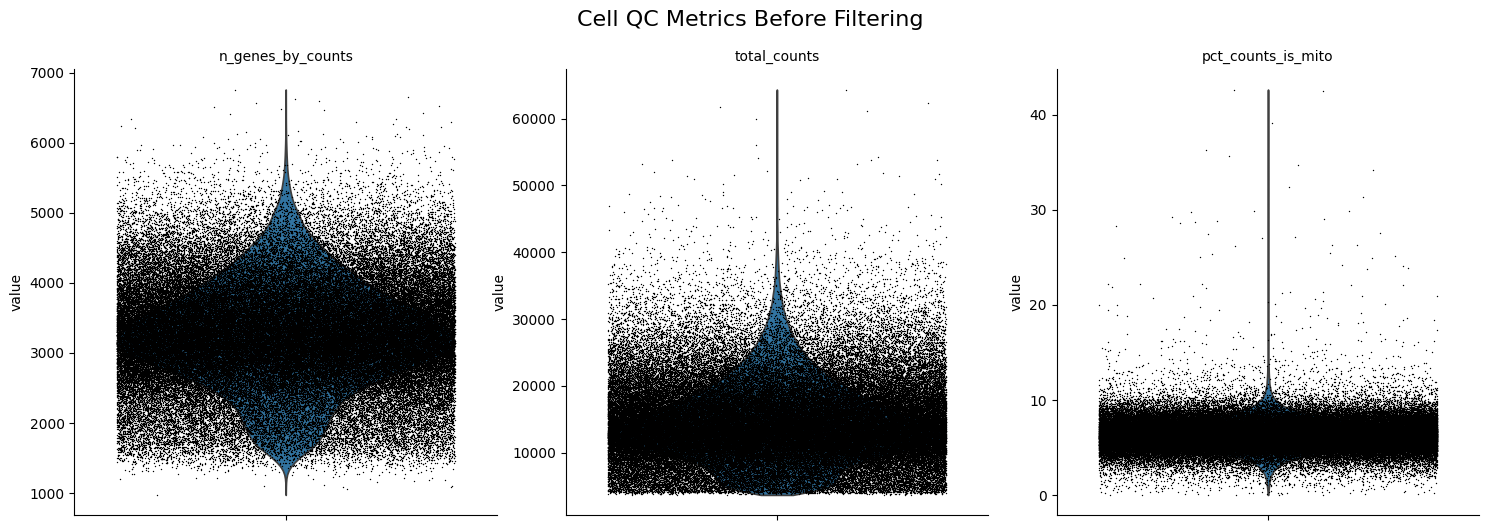

In [10]:
# Define filename of plot
qc_before_filtering_file = FIGURES_DIR / "01_cell_qc_before_filtering.png"

# Create the plot
ax = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_is_mito"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)

# Set a title for the entire figure
plt.suptitle("Cell QC Metrics Before Filtering", fontsize=16, y=1.05)

# Save the plot
plt.savefig(str(qc_before_filtering_file), bbox_inches="tight")

# Show plot
plt.show()

#### 3.1.3. Filter Cells

##### 3.1.3.1. Define Function To Calculate MAD-Based Thresholds
MAD stands for Median Absolute Deviation and is context-specific to a dataset, eliminating the need to hard-set thresholds.
- The value of `nmads=3.5` was set after iterative experimentation, and is not arbitrary.

In [11]:
def mad_threshold(data, nmads=3.5):
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    return median - nmads * mad, median + nmads * mad

print("Function to calculate MAD-based thresholds defined successfully.")

Function to calculate MAD-based thresholds defined successfully.


##### 3.1.3.2. Calculate MAD-Based Thresholds

- Thresholds For n_genes_by_counts  
  - For filtering cells that express too few or too many unique genes.

In [12]:
n_genes_low, n_genes_high = mad_threshold(adata.obs["n_genes_by_counts"])
print(f"n_genes_by_counts thresholds: {n_genes_low:.0f} to {n_genes_high:.0f}")
print(
    f"  Cells with < {n_genes_low:.0f} genes are likely empty droplets (no real cell captured)."
)
print(
    f"  Cells with > {n_genes_high:.0f} genes are likely multiplets (two or more cells in one droplet)."
)
print(
    f"  Therefore, cells with fewer than {n_genes_low:.0f} genes or more than {n_genes_high:.0f} genes will be filtered out."
)

n_genes_by_counts thresholds: 1584 to 4882
  Cells with < 1584 genes are likely empty droplets (no real cell captured).
  Cells with > 4882 genes are likely multiplets (two or more cells in one droplet).
  Therefore, cells with fewer than 1584 genes or more than 4882 genes will be filtered out.


- Thresholds For total_counts
  - For filtering cells that were sequenced too deeply or too shallow.

In [13]:
total_counts_low, total_counts_high = mad_threshold(adata.obs["total_counts"])
print(f"\ntotal_counts thresholds: {total_counts_low:.0f} to {total_counts_high:.0f}")
print(
    f"  Cells with < {total_counts_low:.0f} UMIs are too lowly sequenced to be informative."
)
print(f"  Cells with > {total_counts_high:.0f} UMIs are likely multiplets.")
print(
    f"  Therefore, cells with fewer than {total_counts_low:.0f} UMIs or more than {total_counts_high:.0f} UMIs will be filtered out."
)


total_counts thresholds: 1504 to 26206
  Cells with < 1504 UMIs are too lowly sequenced to be informative.
  Cells with > 26206 UMIs are likely multiplets.
  Therefore, cells with fewer than 1504 UMIs or more than 26206 UMIs will be filtered out.


- Thresholds For pct_counts_is_mito
  - For filtering cells that express too many mitochondrial genes, signaling that they are damaged or dead.

In [14]:
mito_low, mito_high = mad_threshold(adata.obs["pct_counts_is_mito"])
print(f"\npct_counts_is_mito thresholds: {mito_low:.2f}% - {mito_high:.2f}%")
print(
    f"  Cells with > {mito_high:.2f}% mitochondrial counts are likely damaged or dying cells."
)
print(
    f"  Lower mito% bound is ignored as abnormally low mito% is not a quality concern."
)
print(
    f"  Therefore, cells with more than {mito_high:.2f}% mitochondrial counts will be filtered out."
)


pct_counts_is_mito thresholds: 3.17% - 9.46%
  Cells with > 9.46% mitochondrial counts are likely damaged or dying cells.
  Lower mito% bound is ignored as abnormally low mito% is not a quality concern.
  Therefore, cells with more than 9.46% mitochondrial counts will be filtered out.


##### 3.1.3.3. Filter Cells Using Thresholds

In [15]:
# Store cell count before filtering
n_cells_before = adata.n_obs
print(f"\nNumber of cells before filtering: {n_cells_before}")

# Apply filters
print("\nApplying filters to remove low-quality cells....")
adata = adata[
    # Filter based on n_genes_by_counts
    (adata.obs["n_genes_by_counts"] >= n_genes_low)
    & (adata.obs["n_genes_by_counts"] <= n_genes_high)

    # Filter based on total_counts
    & (adata.obs["total_counts"] >= total_counts_low)
    & (adata.obs["total_counts"] <= total_counts_high)

    # Filter based on pct_counts_is_mito
    & (adata.obs["pct_counts_is_mito"] <= mito_high)
].copy()
print("Filters applied successfully.")

# Report
n_cells_after = adata.n_obs
print(f"Number of cells after filtering: {n_cells_after}")

n_cells_removed = n_cells_before - n_cells_after
print(f"\nNumber of cells removed: {n_cells_before} - {n_cells_after} = {n_cells_removed} ({n_cells_removed/n_cells_before*100:.1f}%)")



Number of cells before filtering: 111445

Applying filters to remove low-quality cells....
Filters applied successfully.
Number of cells after filtering: 102649

Number of cells removed: 111445 - 102649 = 8796 (7.9%)


##### 3.1.3.4. Filter Remaining Doublets
Use `scrublet` to remove any remaining doublets.

In [16]:
# Store cell count before filtering
n_cells_before_scrublet = adata.n_obs
print(f"\nNumber of cells before doublet removal: {n_cells_before_scrublet}")

# Run Scrublet to predict doublets
print("\nRunning Scrublet to predict doublets....\n")
scrub = scr.Scrublet(adata.X)
doublet_scores, predicted_doublets = scrub.scrub_doublets()

adata.obs["doublet_score"] = doublet_scores
adata.obs["predicted_doublet"] = predicted_doublets

n_doublets = predicted_doublets.sum()
print(f"\nPredicted doublets: {n_doublets} ({n_doublets/adata.n_obs*100:.1f}% of the total cells)")

# Remove predicted doublets
adata = adata[~adata.obs["predicted_doublet"]].copy()
print(f"Number of cells after doublet removal: {adata.n_obs}")


Number of cells before doublet removal: 102649

Running Scrublet to predict doublets....

Preprocessing...


c:\Users\Acer\miniforge3\envs\crisprmod_env\Lib\site-packages\scrublet\helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.37
Detected doublet rate = 2.5%
Estimated detectable doublet fraction = 37.8%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 6.7%
Elapsed time: 266.8 seconds

Predicted doublets: 2602 (2.5% of the total cells)
Number of cells after doublet removal: 100047


#### 3.1.4. Plot QC Metrics After Filtering

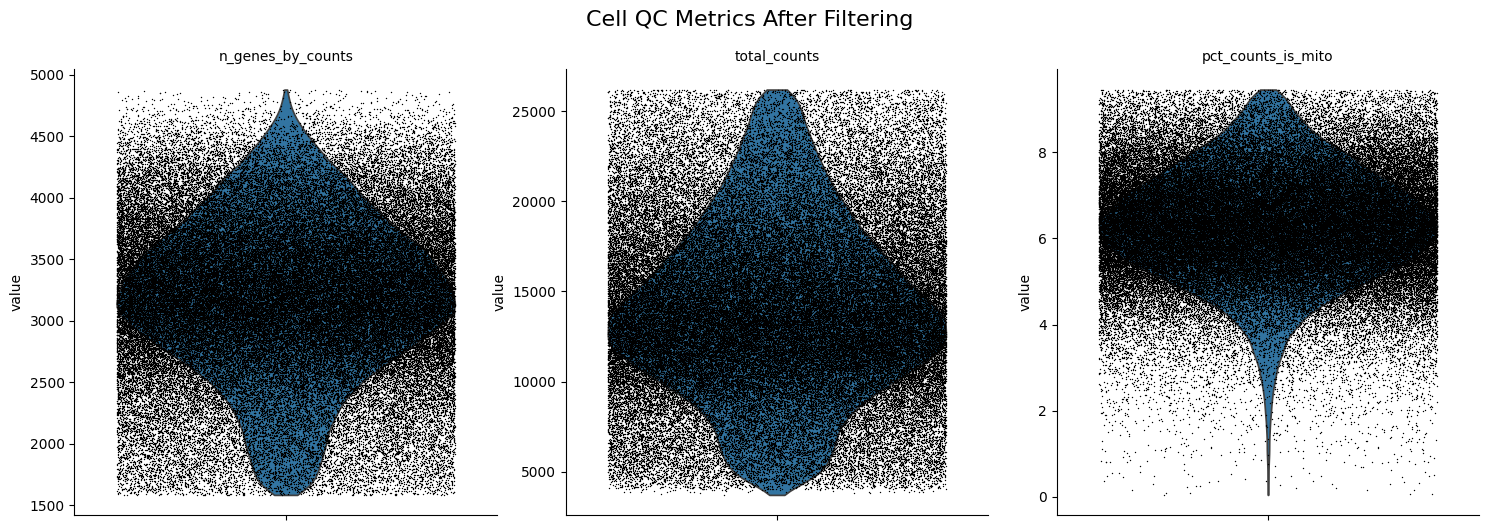

In [17]:
# Define filename of plot
qc_after_filtering_file = FIGURES_DIR / "02_cell_qc_after_filtering.png"

# Create the plot
ax = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_is_mito"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)

# Set a title for the entire figure
plt.suptitle("Cell QC Metrics After Filtering", fontsize=16, y=1.05)

# Save the plot
plt.savefig(str(qc_after_filtering_file), bbox_inches="tight")

# Show plot
plt.show()

### 3.2. Filter Low-Quality Genes
Remove genes that are expressed in less than 10 cells.

In [18]:
# Store gene count before filtering
n_genes_before = adata.n_vars
print(f"\nNumber of genes before filtering: {n_genes_before}")

# Filter genes
print("\nFiltering genes that are expressed in less than 10 cells....")
sc.pp.filter_genes(adata, min_cells=10)
print("Filter applied successfully.")

# Report
n_genes_after = adata.n_vars
print(f"Number of genes after filtering:  {n_genes_after}")

n_genes_removed = n_genes_before - n_genes_after
print(
    f"\nNumber of genes removed: {n_genes_before} - {n_genes_after} = {n_genes_removed} ({n_genes_removed/n_genes_before*100:.1f}%)"
)


Number of genes before filtering: 33694

Filtering genes that are expressed in less than 10 cells....
Filter applied successfully.
Number of genes after filtering:  19996

Number of genes removed: 33694 - 19996 = 13698 (40.7%)


---

## 4. Perform Final Sanity Checks

In [19]:
print("=== POST-QC SANITY CHECK ===\n")

# Verify gene symbols are set as index (not Ensembl IDs)
assert not adata.var_names.str.startswith("ENSG").any(), "Ensembl IDs still present"

# Verify cell barcodes are unique
assert adata.obs_names.is_unique, "Cell barcodes are not unique"

# Verify raw UMI counts are whole numbers
assert np.all(
    adata.X.data == np.floor(adata.X.data)
), "Non-integer values in count matrix"

# Verify no cells exceed thresholds
assert (
    adata.obs["n_genes_by_counts"].min() >= n_genes_low
), "n_genes lower bound violated"
assert (
    adata.obs["n_genes_by_counts"].max() <= n_genes_high
), "n_genes upper bound violated"
assert (
    adata.obs["total_counts"].min() >= total_counts_low
), "total_counts lower bound violated"
assert (
    adata.obs["total_counts"].max() <= total_counts_high
), "total_counts upper bound violated"
assert adata.obs["pct_counts_is_mito"].max() <= mito_high, "mito upper bound violated"

# Verify no predicted doublets remain
assert adata.obs["predicted_doublet"].sum() == 0, "Doublets still present"

print("All assertions passed.")

print(
    f"\nCells removed total: {111445 - adata.n_obs} ({(111445 - adata.n_obs)/111445*100:.1f}%)"
)
print(
    f"Genes removed total: {33694 - adata.n_vars} ({(33694 - adata.n_vars)/33694*100:.1f}%)"
)

# Cell and gene counts
print(f"Final dataset: {adata.n_obs} cells x {adata.n_vars} genes")

# Show sample cell IDs, gene symbols, and data matrix values
print("\nSample cell IDs:\n", adata.obs_names[:5])
print("\nSample gene symbols:\n", adata.var_names[:5])
print("\nSample data matrix (first 5 rows and columns):\n", adata.X[:5, :5].toarray())

=== POST-QC SANITY CHECK ===

All assertions passed.

Cells removed total: 11398 (10.2%)
Genes removed total: 13698 (40.7%)
Final dataset: 100047 cells x 19996 genes

Sample cell IDs:
 Index(['AAACCTGAGGCATGTG-1', 'AAACCTGAGGCCCTTG-1', 'AAACCTGCACGAAGCA-1',
       'AAACCTGCAGCCTTGG-1', 'AAACCTGCATCTCCCA-1'],
      dtype='object', name='index')

Sample gene symbols:
 Index(['RP11-34P13.3', 'RP11-34P13.7', 'FO538757.3', 'FO538757.2',
       'AP006222.2'],
      dtype='object')

Sample data matrix (first 5 rows and columns):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 2.]
 [0. 0. 0. 0. 0.]]


---

## 5. Save Cleaned AnnData

In [20]:
adata.write_h5ad(CLEANED_ANNDATA_FILE)
print(f"Saved: {CLEANED_ANNDATA_FILE}")

Saved: ..\01_data\02_processed\Norman_2019_cleaned.h5ad


---

## 6. Summary

### 6.1. Data Validation
- Gene symbols confirmed as index (no Ensembl IDs)
- Cell barcodes confirmed unique
- Raw UMI counts confirmed as integers

### 6.2. QC Thresholds Used (`nmads=3.5`)
- Cell QC
  - n_genes_by_counts (number of unique genes expressed): 1584 to 4882
  - total_counts (total UMI count of all genes): 1504 to 26206
  - pct_counts_is_mito (percentage of mitochondrial genes): ≤ 9.46%
- Gene QC
  - Genes expressed in < 10 cells removed

### 6.3. QC Steps Executed
| Step | Before | After | Removed |
|------|--------|-------|---------|
| MAD filtering (cells) | 111,445 | 102,649 | 8,796 (7.9%) |
| Scrublet doublet removal | 102,649 | 100,047 | 2,602 (2.5%) |
| Gene filtering | 33,694 | 19,996 | 13,698 (40.7%) |
| **Final dataset** | | **100,047 cells x 19,996 genes** | |